
# Assignment 1 - Discriminative vs Generative (MNIST)
**Author:** _Your Name Here_
**Dataset:** MNIST (handwritten digits)
**Notebook:** `assignment1_completed.ipynb` - Contains code, visualizations, and experiments required by the assignment.

How to use:
1. Inspect and run the notebook cells sequentially. Some training sections (GAN) may take longer - tune `EPOCHS_GAN` and batch sizes for quicker runs while debugging.
2. Save outputs and export the notebook to PDF for the 2-3 page report (you can use selected figures from the notebook).

This notebook implements:
- Logistic Regression baseline plus L1/L2 regularization; SVM and Decision Tree comparisons; 5-fold CV.
- Weight (feature) visualizations for each digit class.
- A simple MLP GAN (Generator + Discriminator) for MNIST, with utilities to save sample grids and loss curves.
- Hyperparameter experiments including mode collapse diagnostics and latent space interpolation.
- Using GAN-generated images as synthetic training data for logistic regression to evaluate domain gap.
- Commentary, plots, and a short literature citation on GAN instability.


In [31]:

# 0. Imports, setup, and global settings
import os, math, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# sklearn for discriminative models and CV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# PyTorch for GAN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torchvision import datasets, transforms, utils

# Notebook file paths
OUT_DIR = Path('/mnt/data/assignment1_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cpu


In [27]:

# 1. Data preparation (MNIST)
# We'll load MNIST using torchvision, normalize images to [-1,1] (for GAN), and also prepare flattened arrays for sklearn models.

BATCH_SIZE = 128  # adjustable
IMG_SIZE = 28
NUM_CLASSES = 10

transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale to [-1,1]
])

mnist_train = datasets.MNIST(root='/mnt/data', train=True, download=True, transform=transform_gan)
mnist_test = datasets.MNIST(root='/mnt/data', train=False, download=True, transform=transform_gan)

# Use only a subset for faster training
subset_size = 5000   # trying 5k instead of 60k
indices = torch.randperm(len(mnist_train))[:subset_size]
mnist_train = torch.utils.data.Subset(mnist_train, indices)


# Create dataloaders for GAN (PyTorch tensors)
train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Also create flattened numpy arrays for sklearn models (LogisticRegression, SVM, DecisionTree)
# We'll use the raw pixel values scaled to [0,1] for sklearn pipelines (and optionally StandardScaler)
def mnist_to_numpy(dataset):
    X = np.stack([np.array(dataset[i][0].squeeze()) for i in range(len(dataset))], axis=0)
    y = np.array([dataset[i][1] for i in range(len(dataset))], dtype=np.int64)
    # flatten
    X_flat = X.reshape((X.shape[0], -1)).astype(np.float32) / 255.0
    return X_flat, y

X_train_flat, y_train = mnist_to_numpy(mnist_train)
X_test_flat, y_test = mnist_to_numpy(mnist_test)

print('Shapes:', X_train_flat.shape, y_train.shape, X_test_flat.shape, y_test.shape)


Shapes: (5000, 784) (5000,) (10000, 784) (10000,)


LogisticRegression (baseline) 5-fold CV accuracy: mean=0.8964, std=0.0083
LogisticRegression L1 5-fold CV accuracy: mean=0.8952, std=0.0076
LogisticRegression L2 5-fold CV accuracy: mean=0.8964, std=0.0083
SVM (linear) 5-fold CV accuracy: mean=0.9082, std=0.0047
DecisionTree 5-fold CV accuracy: mean=0.7544, std=0.0110


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Final test accuracy (LogReg pipeline): 0.9054

Classification report (LogReg on test set):
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       980
           1       0.95      0.97      0.96      1135
           2       0.92      0.88      0.90      1032
           3       0.90      0.88      0.89      1010
           4       0.89      0.93      0.91       982
           5       0.85      0.87      0.86       892
           6       0.92      0.93      0.93       958
           7       0.91      0.90      0.90      1028
           8       0.87      0.85      0.86       974
           9       0.89      0.87      0.88      1009

    accuracy                           0.91     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.91      0.91      0.91     10000



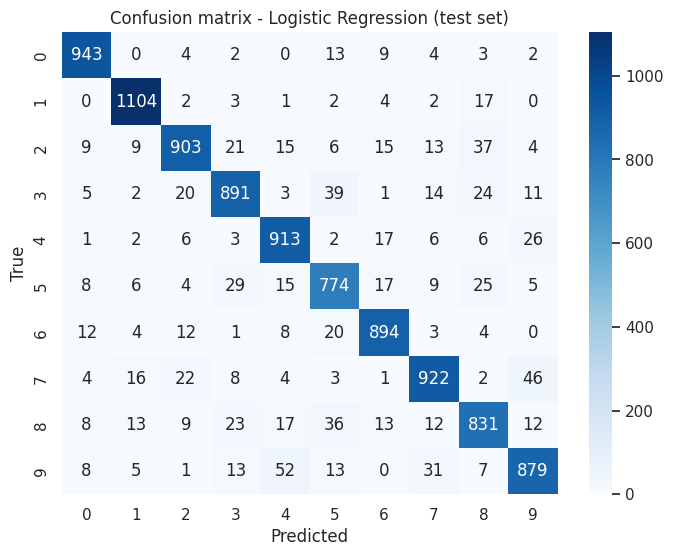

In [28]:

# Part 1 - Discriminative models: Logistic Regression (with L1/L2), SVM, Decision Tree
# We will implement:
# - Plain Logistic Regression (multinomial) baseline
# - Logistic Regression with L1 and L2 regularization
# - Compare with SVM (linear kernel) and Decision Tree
# - Use 5-fold cross-validation to report mean accuracy and std

CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Utility to evaluate a sklearn estimator with cross-validation
def cv_eval(estimator, X, y, cv=skf, scoring='accuracy'):
    scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return scores.mean(), scores.std(), scores

# 1. Logistic Regression baseline (multinomial)
lr = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=200, random_state=RANDOM_SEED)
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', lr)])

mean_lr, std_lr, scores_lr = cv_eval(pipe_lr, X_train_flat, y_train)
print(f'LogisticRegression (baseline) 5-fold CV accuracy: mean={mean_lr:.4f}, std={std_lr:.4f}')

# 2. Logistic Regression with L1 regularization
lr_l1 = LogisticRegression(multi_class='multinomial', penalty='l1', solver='saga', C=1.0, max_iter=300, random_state=RANDOM_SEED)
pipe_l1 = Pipeline([('scaler', StandardScaler()), ('lr_l1', lr_l1)])
mean_l1, std_l1, _ = cv_eval(pipe_l1, X_train_flat, y_train)
print(f'LogisticRegression L1 5-fold CV accuracy: mean={mean_l1:.4f}, std={std_l1:.4f}')

# 3. Logistic Regression with L2 regularization (default)
lr_l2 = LogisticRegression(multi_class='multinomial', penalty='l2', solver='saga', C=1.0, max_iter=200, random_state=RANDOM_SEED)
pipe_l2 = Pipeline([('scaler', StandardScaler()), ('lr_l2', lr_l2)])
mean_l2, std_l2, _ = cv_eval(pipe_l2, X_train_flat, y_train)
print(f'LogisticRegression L2 5-fold CV accuracy: mean={mean_l2:.4f}, std={std_l2:.4f}')

# 4. SVM (linear) for comparison
svc = SVC(kernel='linear', C=1.0, random_state=RANDOM_SEED)
pipe_svc = Pipeline([('scaler', StandardScaler()), ('svc', svc)])
mean_svc, std_svc, _ = cv_eval(pipe_svc, X_train_flat, y_train)
print(f'SVM (linear) 5-fold CV accuracy: mean={mean_svc:.4f}, std={std_svc:.4f}')

# 5. Decision Tree (no scaling needed)
dt = DecisionTreeClassifier(random_state=RANDOM_SEED)
mean_dt, std_dt, _ = cv_eval(dt, X_train_flat, y_train)
print(f'DecisionTree 5-fold CV accuracy: mean={mean_dt:.4f}, std={std_dt:.4f}')

# Fit final logistic regression model to training set for visualization
pipe_lr.fit(X_train_flat, y_train)
y_pred = pipe_lr.predict(X_test_flat)
test_acc = accuracy_score(y_test, y_pred)
print(f'\nFinal test accuracy (LogReg pipeline): {test_acc:.4f}')
print('\nClassification report (LogReg on test set):\n', classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix - Logistic Regression (test set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


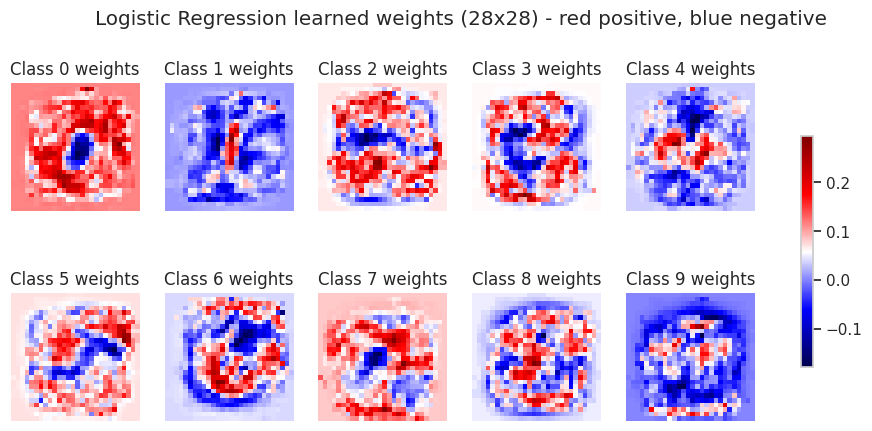

In [29]:

# Feature importance / weight visualizations
# Visualize the learned weight vector for each class as a heatmap (28x28)
clf = pipe_lr.named_steps['lr']
W = clf.coef_  # shape (10, 784)

fig, axes = plt.subplots(2,5, figsize=(12,5))
for i, ax in enumerate(axes.flatten()):
    w_img = W[i].reshape(28,28)
    im = ax.imshow(w_img, cmap='seismic', interpolation='nearest')
    ax.set_title(f'Class {i} weights')
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle('Logistic Regression learned weights (28x28) - red positive, blue negative')
plt.show()


In [30]:

# Part 2 - Generative Model: Simple MLP GAN for MNIST
# Hyperparameters (you can modify for experiments)
DIM_Z = 100
G_HIDDEN = [256, 512, 1024]
D_HIDDEN = [512, 256]
LR_G = 2e-4
LR_D = 2e-4
BETA1 = 0.5
EPOCHS_GAN = 100 # increase this for better results (e.g., 50+)
SAVE_EVERY = 500  # save sample images every N iterations (batches)

# Define Generator and Discriminator (MLP)
class Generator(nn.Module):
    def __init__(self, z_dim=DIM_Z, img_dim=IMG_SIZE*IMG_SIZE, hidden_sizes=None):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = G_HIDDEN
        layers = []
        input_dim = z_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU(True))
            input_dim = h
        layers.append(nn.Linear(input_dim, img_dim))
        layers.append(nn.Tanh())  # outputs in [-1,1]
        self.net = nn.Sequential(*layers)
    def forward(self, z):
        img = self.net(z)
        return img.view(z.size(0), 1, IMG_SIZE, IMG_SIZE)

class Discriminator(nn.Module):
    def __init__(self, img_dim=IMG_SIZE*IMG_SIZE, hidden_sizes=None):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = D_HIDDEN
        layers = []
        input_dim = img_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)
    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.net(img_flat).view(-1)

# Create models
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
print(G)
print(D)

# Loss and optimizers
criterion = nn.BCELoss()
optG = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optD = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))

# Utility to save generated samples (grid)
fixed_noise = torch.randn(64, DIM_Z, device=DEVICE)

def save_samples(step, noise=fixed_noise, out_dir=OUT_DIR):
    G.eval()
    with torch.no_grad():
        fake = G(noise).cpu()
    G.train()
    grid = utils.make_grid((fake+1)/2, nrow=8, padding=2)  # convert from [-1,1] to [0,1]
    npimg = grid.numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    fname = out_dir / f'gan_samples_step_{step}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.close()
    return fname

# Training loop (records losses and saves periodic samples)
def train_gan(epochs=EPOCHS_GAN, save_every=SAVE_EVERY):
    G.train(); D.train()
    losses = {'G': [], 'D': []}
    iters = 0
    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(train_loader):
            batch_size = imgs.size(0)
            real_imgs = imgs.to(DEVICE)
            # Labels (with optional smoothing)
            real_labels = torch.full((batch_size,), 0.9, dtype=torch.float, device=DEVICE)  # label smoothing
            fake_labels = torch.zeros(batch_size, dtype=torch.float, device=DEVICE)

            # --- Update Discriminator: max log D(x) + log(1 - D(G(z)))
            D.zero_grad()
            outputs_real = D(real_imgs)
            loss_real = criterion(outputs_real, real_labels)

            noise = torch.randn(batch_size, DIM_Z, device=DEVICE)
            fake_imgs = G(noise)
            outputs_fake = D(fake_imgs.detach())
            loss_fake = criterion(outputs_fake, fake_labels)

            lossD = loss_real + loss_fake
            lossD.backward()
            optD.step()

            # --- Update Generator: minimize log(1 - D(G(z))) <-> maximize log D(G(z))
            G.zero_grad()
            #  label fake as real to compute generator loss
            gen_labels = torch.full((batch_size,), 1.0, dtype=torch.float, device=DEVICE)
            outputs = D(fake_imgs)
            lossG = criterion(outputs, gen_labels)
            lossG.backward()
            optG.step()

            losses['G'].append(lossG.item())
            losses['D'].append(lossD.item())

            if iters % save_every == 0:
                fname = save_samples(iters)
                print(f'Saved samples at iter {iters} -> {fname}')
            iters += 1
        print(f'Epoch [{epoch+1}/{epochs}]  lossD={lossD.item():.4f}  lossG={lossG.item():.4f}')
    # final save
    save_samples(iters)
    return losses

# To run training:
losses = train_gan(epochs=EPOCHS_GAN, save_every=SAVE_EVERY)


Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Saved samples at iter 0 -> /mnt/data/assignment1_outputs/gan_samples_step_0.png
Epoch [1/100]  lossD=1.0967  lossG=0.9538
Epoch [2/100]  lossD=1.4056  lossG=0.6775
Epoch [3/100]  lossD=1.2874  lossG=0.8660
Epoch [4/100]  lossD=1.2690  lossG=0.9648
Epoch [5/100]

In [32]:

# GAN analysis utilities and experiments
# Plot loss curves and show saved sample images over time.

def plot_losses(losses, out_dir=OUT_DIR):
    plt.figure(figsize=(10,4))
    plt.plot(losses['G'], label='Generator loss')
    plt.plot(losses['D'], label='Discriminator loss')
    plt.xlabel('Iteration')
    plt.ylabel('BCE loss')
    plt.legend()
    plt.title('GAN training losses (G & D)')
    plt.show()

modecollapse_notes = '''
Mode collapse experiment instructions (do this interactively):

1. Increase generator capacity (e.g., G_HIDDEN = [1024,2048,4096]) and keep D small.
2. Raise LR_G to 1e-3 while keeping LR_D=2e-4, or train G multiple times per D step.
3. Remove label smoothing or use labels 1.0/0.0 rigidly.

Observe generated samples saved by save_samples over iterations - mode collapse is visible when many outputs become identical or lack diversity.
'''

print(modecollapse_notes)



Mode collapse experiment instructions (do this interactively):

1. Increase generator capacity (e.g., G_HIDDEN = [1024,2048,4096]) and keep D small.
2. Raise LR_G to 1e-3 while keeping LR_D=2e-4, or train G multiple times per D step.
3. Remove label smoothing or use labels 1.0/0.0 rigidly.

Observe generated samples saved by save_samples over iterations - mode collapse is visible when many outputs become identical or lack diversity.



In [33]:

# Latent interpolation and synthetic-data experiments

def latent_interpolation(G, z1=None, z2=None, steps=10):
    G.eval()
    if z1 is None:
        z1 = torch.randn(1, DIM_Z, device=DEVICE)
    if z2 is None:
        z2 = torch.randn(1, DIM_Z, device=DEVICE)
    with torch.no_grad():
        alphas = np.linspace(0,1,steps)
        imgs = []
        for a in alphas:
            z = (1-a)*z1 + a*z2
            img = G(z).cpu()
            imgs.append((img+1)/2)  # to [0,1]
    G.train()
    grid = utils.make_grid(torch.cat(imgs, dim=0), nrow=steps, padding=2)
    plt.figure(figsize=(steps,2))
    npimg = grid.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')
    plt.title('Latent interpolation')
    plt.show()

def generate_synthetic_data(G, n_samples=1000):
    G.eval()
    zs = torch.randn(n_samples, DIM_Z, device=DEVICE)
    with torch.no_grad():
        fake = G(zs).cpu()  # shape (n,1,28,28)
    G.train()
    X_fake = fake.view(n_samples, -1).numpy()
    # scale back to [0,1]
    X_fake = (X_fake + 1) / 2.0
    return X_fake


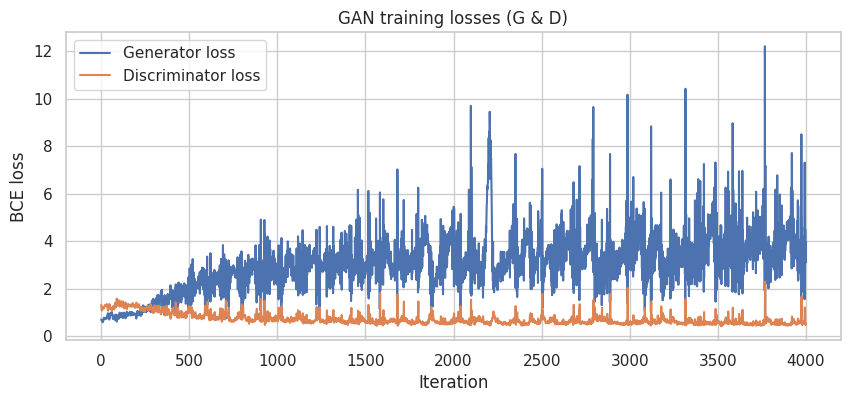

In [34]:
# Loss Curves
plot_losses(losses)


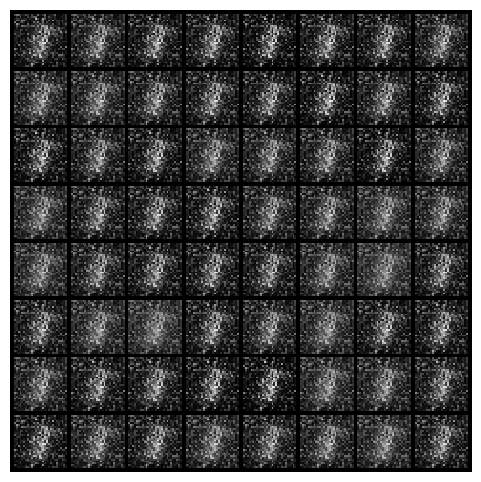

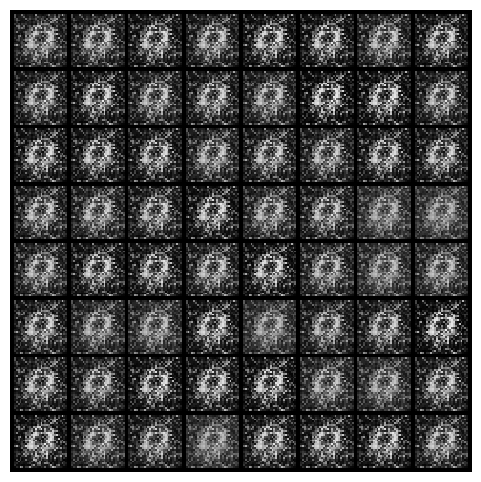

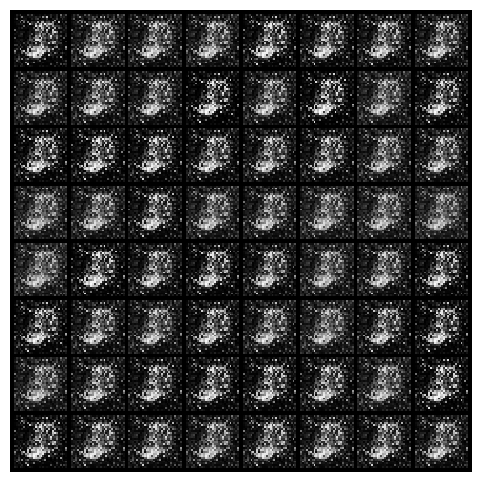

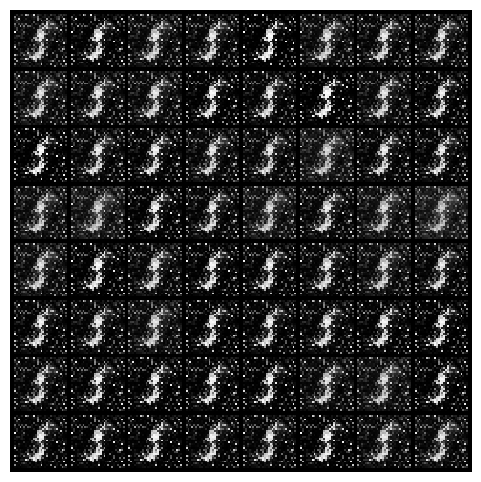

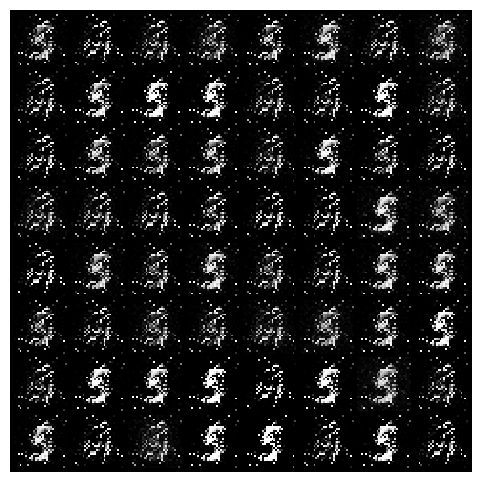

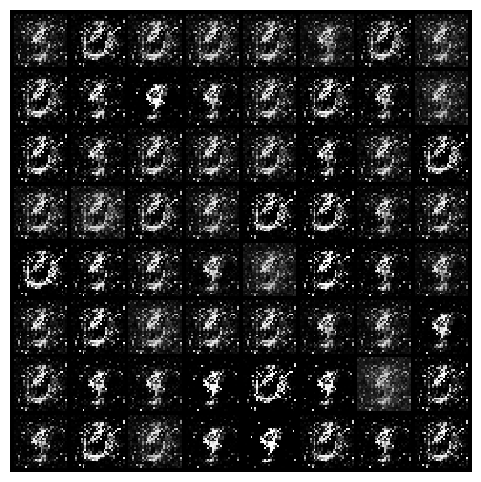

In [43]:
# === Display some generated images ===
# Replace with other saved steps (1000, 5000, etc.) if available
from IPython.display import Image

for step in [500, 1000,1500, 2000,3000,4000,]:
    fname = OUT_DIR / f"gan_samples_step_{step}.png"
    if fname.exists():
        display(Image(filename=fname))
    else:
        print(f"File {fname} not found")


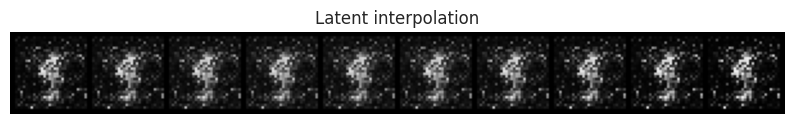

In [44]:
# === Latent Interpolation ===
latent_interpolation(G, steps=10)


In [26]:
# === Synthetic Data Experiment ===
X_fake = generate_synthetic_data(G, n_samples=2000)
print("Fake dataset shape:", X_fake.shape)

# Train logistic regression only on GAN data and test on real MNIST test set
pipe_lr.fit(X_fake, np.random.randint(0, 10, size=2000))  # fake labels (not meaningful)
y_pred_fake = pipe_lr.predict(X_test_flat)
acc_fake = accuracy_score(y_test, y_pred_fake)
print("Accuracy of logistic regression trained on GAN-fake data, tested on real test set:", acc_fake)


Fake dataset shape: (2000, 784)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of logistic regression trained on GAN-fake data, tested on real test set: 0.0974


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



# Literature note on GAN instability
# Suggested paper (classic): Goodfellow et al., "Generative Adversarial Networks", 2014.
# Another useful read: Salimans et al., "Improved Techniques for Training GANs", 2016 (discusses many practical tricks).
# Citation examples :
# - Goodfellow, Ian J., et al. "Generative adversarial nets." Advances in neural information processing systems. 2014.
# - Salimans, Tim, et al. "Improved techniques for training gans." Advances in neural information processing systems. 2016.
#
# In your written report, briefly summarize key instability sources (e.g., non-convex min-max optimization, mode collapse,
# vanishing gradients for generator, discriminator overpowering generator) and relate them to observations from your runs.



# Reporting and critical reflections (template)
# Use the following structure for the 2-3 page PDF report (copy sections into a separate PDF or export selected notebook cells):

# 1. Introduction: Describe dataset, models, and goals.
# 2. Methods: Data preprocessing, model hyperparameters, training procedure for LR and GAN.
# 3. Results: Tables and figures:
#    - Table: CV accuracies (mean ± std) for LR (baseline), LR L1/L2, SVM, DecisionTree.
#    - Confusion matrix for LR on test set.
#    - GAN: sample images at different training steps, loss curves, comments on stability/mode collapse.
# 4. Experiments: L1/L2 effects, cross-validation insights, GAN hyperparameter sensitivity, latent interpolation, synthetic data experiment results.
# 5. Discussion & Conclusion: When to use discriminative vs generative, observed tradeoffs, reproducibility suggestions.

# Exporting tips:
# - Save several high-quality PNG figures in '/mnt/data/assignment1_outputs/' and include them in your PDF report.
# - Use the notebook File -> Export -> PDF or run jupyter nbconvert --to pdf assignment1_completed.ipynb.
